# Attrition Supervised Machine Learning Predictive Model

## Problem Statement:Create a predictive model that can predict whether Employee  leaving or not the organization.

In [1]:
import pandas as pd
import numpy as np
EmployeeLeftData=pd.read_excel("C:/Users/Ankit Raut/Python IVY Feb-2024 (2)/Python IVY Feb-2024/My ML Projects/Classification Projects/Employee/Employee.xlsx")
print(EmployeeLeftData.shape)
print(EmployeeLeftData.drop_duplicates())
print(EmployeeLeftData.shape)


(4653, 9)
      Education  JoiningYear       City  PaymentTier  Age  Gender EverBenched  \
0     Bachelors         2017  Bangalore            3   34    Male          No   
1     Bachelors         2013       Pune            1   28  Female          No   
2     Bachelors         2014  New Delhi            3   38  Female          No   
3       Masters         2016  Bangalore            3   27    Male          No   
4       Masters         2017       Pune            3   24    Male         Yes   
...         ...          ...        ...          ...  ...     ...         ...   
4645    Masters         2017       Pune            2   31  Female          No   
4647  Bachelors         2016       Pune            3   30    Male          No   
4649    Masters         2013       Pune            2   37    Male          No   
4650    Masters         2018  New Delhi            3   27    Male          No   
4651  Bachelors         2012  Bangalore            3   30    Male         Yes   

      ExperienceI

In [155]:
EmployeeLeftData.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [156]:
EmployeeLeftData.columns

Index(['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender',
       'EverBenched', 'ExperienceInCurrentDomain', 'LeaveOrNot'],
      dtype='str')

## Target Variable is LeaveOrNot

<Axes: xlabel='LeaveOrNot'>

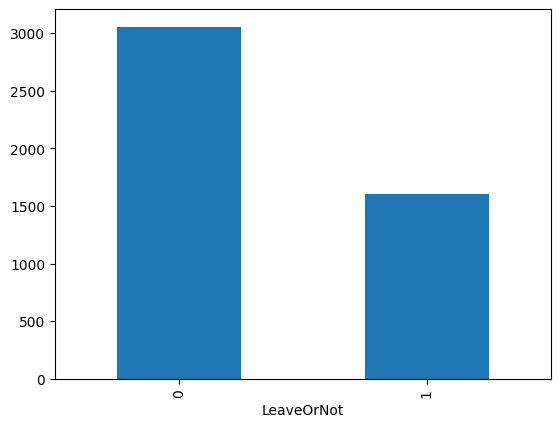

In [157]:
EmployeeLeftData.groupby('LeaveOrNot').size().plot(kind='bar')

## Good Distribution for ML

In [158]:
EmployeeLeftData.nunique()

Education                     3
JoiningYear                   7
City                          3
PaymentTier                   3
Age                          20
Gender                        2
EverBenched                   2
ExperienceInCurrentDomain     8
LeaveOrNot                    2
dtype: int64

## Categorical Columns: 'Education', 'JoiningYear', 'City', 'PaymentTier', 'Gender','EverBenched', 'ExperienceInCurrentDomain', 'LeaveOrNot'
## Continous Columns: 'Age'

In [159]:
EmployeeLeftData.info()

<class 'pandas.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Education                  4653 non-null   str  
 1   JoiningYear                4653 non-null   int64
 2   City                       4653 non-null   str  
 3   PaymentTier                4653 non-null   int64
 4   Age                        4653 non-null   int64
 5   Gender                     4653 non-null   str  
 6   EverBenched                4653 non-null   str  
 7   ExperienceInCurrentDomain  4653 non-null   int64
 8   LeaveOrNot                 4653 non-null   int64
dtypes: int64(5), str(4)
memory usage: 431.5 KB


In [160]:
EmployeeLeftData.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


## Uni Variate Analysis by Bar Charts

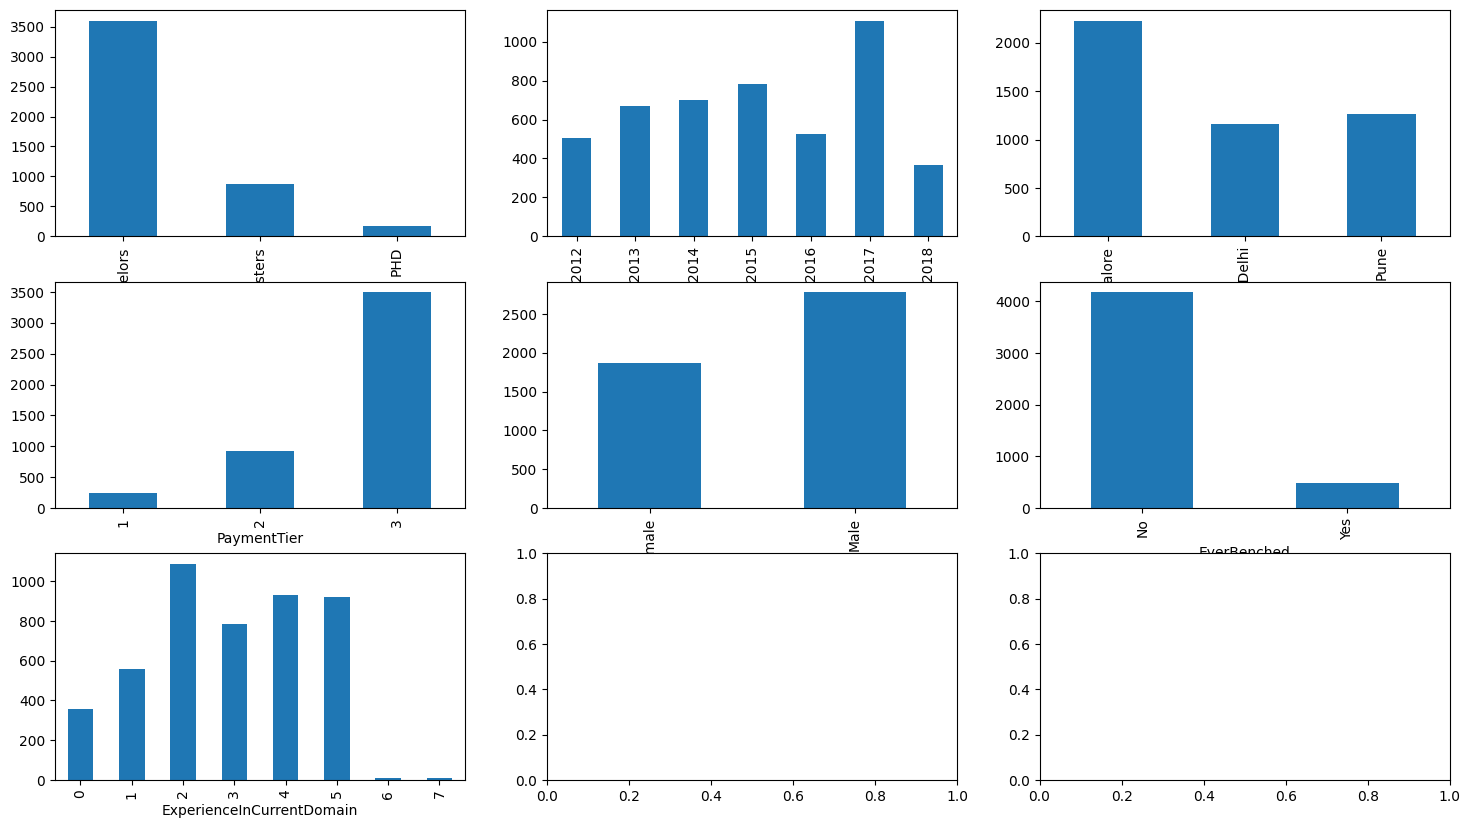

In [161]:
CategoricalColumns= ['Education', 'JoiningYear', 'City', 'PaymentTier', 'Gender','EverBenched', 'ExperienceInCurrentDomain']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(3,3,figsize=(18,10))
subplots=subplots.flatten()
for cols ,no_of_cols in zip(CategoricalColumns,range(len(CategoricalColumns))):
    EmployeeLeftData.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_cols])

### Can be eliminated:EverBenched

## Treating Imbalance

In [2]:
EmployeeLeftData.loc[EmployeeLeftData['ExperienceInCurrentDomain']>=5,'ExperienceInCurrentDomain']=5

<Axes: xlabel='ExperienceInCurrentDomain'>

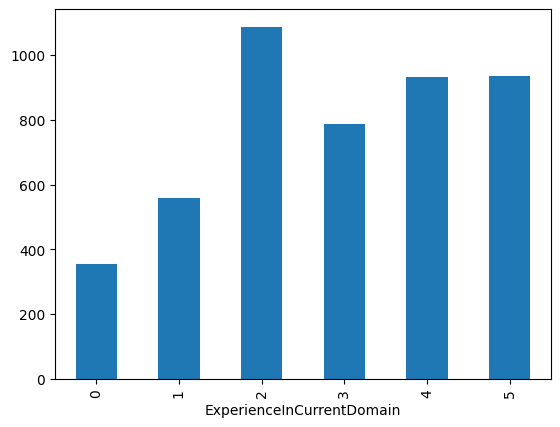

In [163]:
EmployeeLeftData.groupby('ExperienceInCurrentDomain').size().plot(kind='bar')

In [3]:
EmployeeLeftData['ExperienceInCurrentDomain']=EmployeeLeftData['ExperienceInCurrentDomain'].astype('str')

In [165]:
EmployeeLeftData['ExperienceInCurrentDomain']

0       0
1       3
2       2
3       5
4       2
       ..
4648    4
4649    2
4650    5
4651    2
4652    4
Name: ExperienceInCurrentDomain, Length: 4653, dtype: str

In [4]:
EmployeeLeftData.loc[EmployeeLeftData['ExperienceInCurrentDomain']=='5','ExperienceInCurrentDomain']='>5'

<Axes: xlabel='ExperienceInCurrentDomain'>

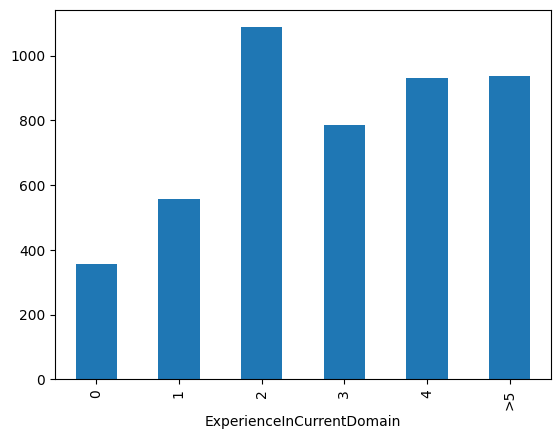

In [167]:
EmployeeLeftData.groupby('ExperienceInCurrentDomain').size().plot(kind='bar')

## Uni Variate Analysis by Histogram

In [168]:
EmployeeLeftData.columns

Index(['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender',
       'EverBenched', 'ExperienceInCurrentDomain', 'LeaveOrNot'],
      dtype='str')

<Axes: >

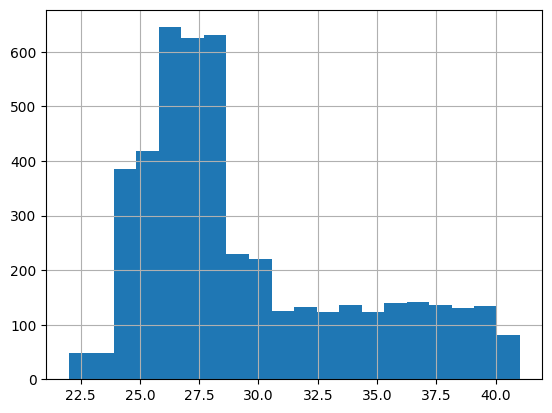

In [169]:
EmployeeLeftData['Age'].hist(bins=20)

## No need of Outlier treatment

In [170]:
EmployeeLeftData.isnull().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

## No need of Missing values treatment

## Categorical Vs Continuous -- Box Plots

<Axes: title={'center': 'Age'}, xlabel='LeaveOrNot'>

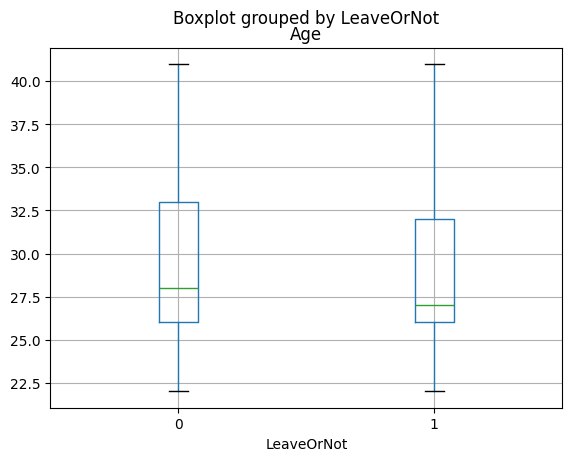

In [171]:
EmployeeLeftData.boxplot(column='Age',by='LeaveOrNot',vert=True)

## Statistical Feature Selection (Categorical Vs Continuous) using ANOVA test

In [172]:
def functionAnova(inpData,cols,targetVariable):
    SelectedPredictor=[]
    from scipy.stats import f_oneway
    CategoricalGroupLists=inpData.groupby(targetVariable)[cols].apply(list)
    AnovaResults=f_oneway(*CategoricalGroupLists)
    if AnovaResults[1]<0.05:
        print(cols,' is correlated with ',targetVariable, ' and p value is:',AnovaResults[1])
        SelectedPredictor.append(cols)
    else:
        print(cols,' is not correlated with ',targetVariable, ' and p value is:',AnovaResults[1])
    return SelectedPredictor
functionAnova(inpData=EmployeeLeftData,cols='Age',targetVariable='LeaveOrNot')

Age  is correlated with  LeaveOrNot  and p value is: 0.0004852123420637579


['Age']

## Relationship exploration: Categorical Vs Categorical -- Grouped Bar Charts

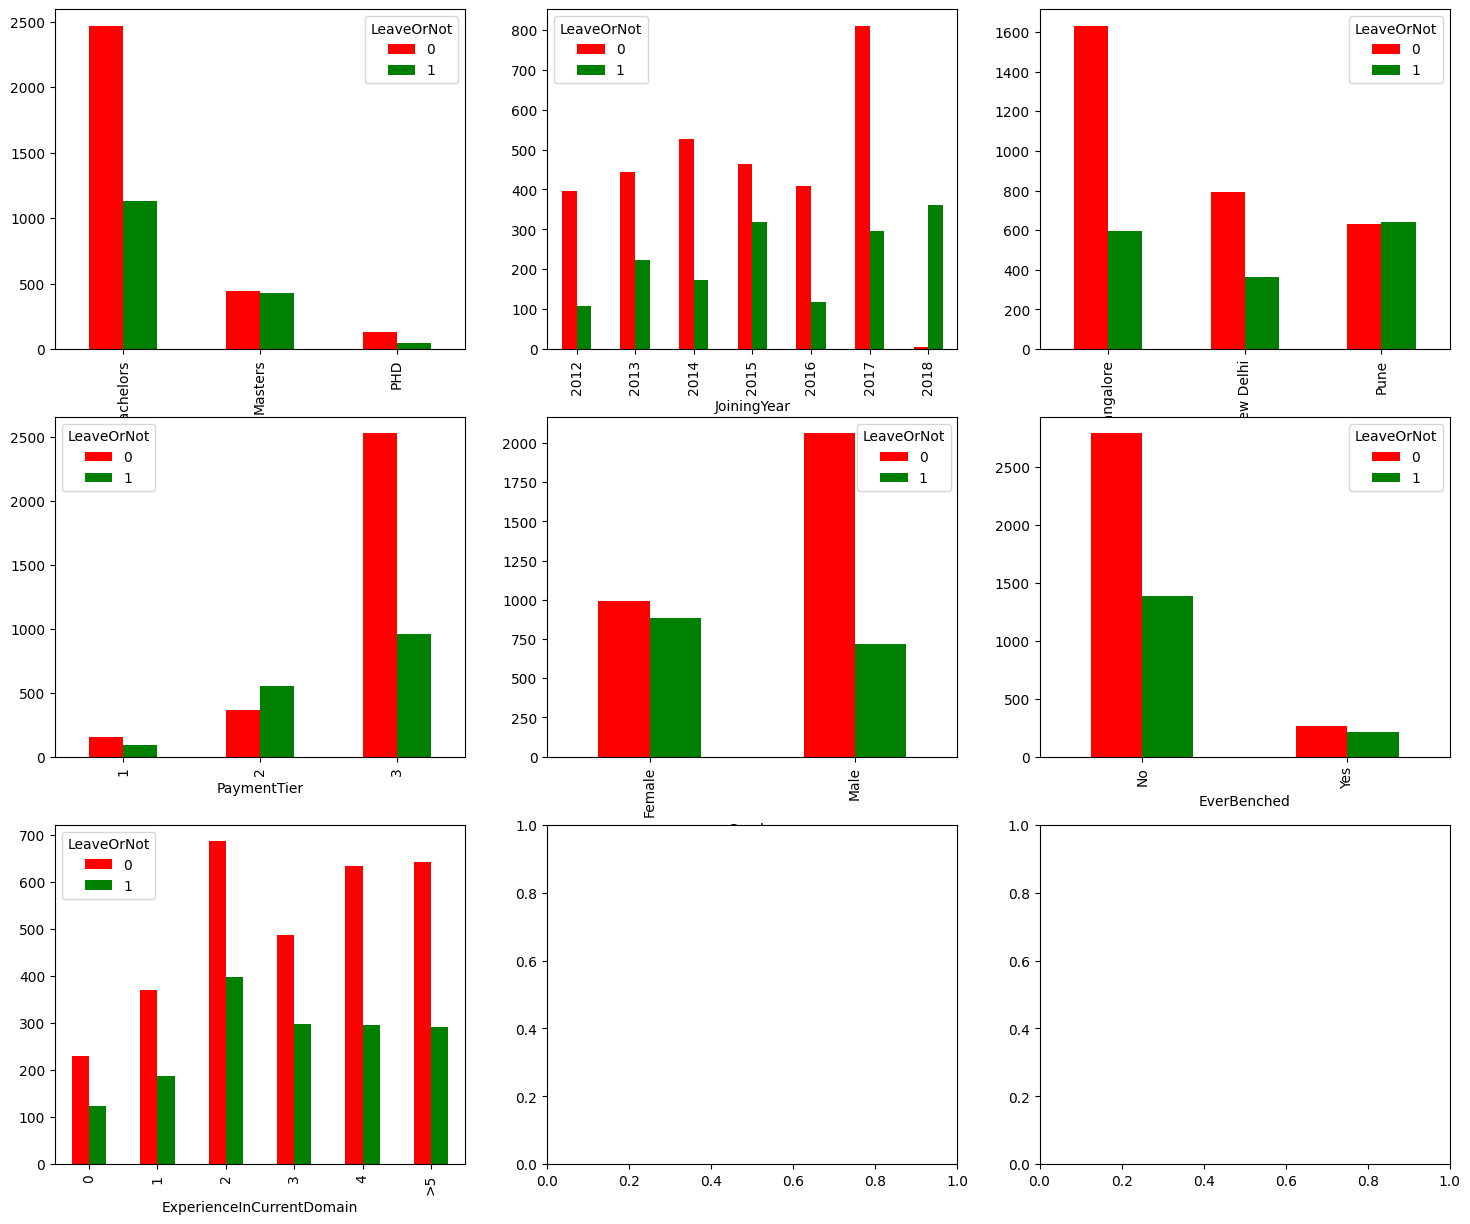

In [173]:
CategoricalColumns= ['Education', 'JoiningYear', 'City', 'PaymentTier', 'Gender','EverBenched', 'ExperienceInCurrentDomain']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(3,3,figsize=(18,15))
subplots=subplots.flatten()
for cols,no_of_cols in zip(CategoricalColumns,range(len(CategoricalColumns))):
    crosstabresults=pd.crosstab(columns=EmployeeLeftData['LeaveOrNot'],index=EmployeeLeftData[cols])
    crosstabresults.plot.bar(color=['red','green'],ax=subplots[no_of_cols])

## Statistical Feature Selection (Categorical Vs Categorical) using Chi-Square Test

In [174]:
CategoricalColumns= ['Education', 'JoiningYear', 'City', 'PaymentTier', 'Gender','EverBenched', 'ExperienceInCurrentDomain']
def chi_2_function(inpData,cols,targetVariable):
    from scipy.stats import chi2_contingency
    SelectedPredictors=[] 
    for cols in CategoricalColumns:
        CrossTabResult=pd.crosstab(columns=inpData[targetVariable],index=inpData[cols])
        chi2_results=chi2_contingency(CrossTabResult)
        if chi2_results[1]<0.05:
            print(cols,' is correlated with LeaveOrNot and p value is:',chi2_results[1])
            SelectedPredictors.append(cols)
        else:
            print(cols,' is not correlated with LeaveOrNot and p value is:',chi2_results[1])
    return SelectedPredictors
chi_2_function(inpData=EmployeeLeftData,cols=CategoricalColumns,targetVariable='LeaveOrNot')
    

Education  is correlated with LeaveOrNot and p value is: 7.724417739147332e-23
JoiningYear  is correlated with LeaveOrNot and p value is: 2.3266155616241426e-172
City  is correlated with LeaveOrNot and p value is: 1.7106992135618012e-45
PaymentTier  is correlated with LeaveOrNot and p value is: 2.9329904732261673e-74
Gender  is correlated with LeaveOrNot and p value is: 5.177873883438753e-51
EverBenched  is correlated with LeaveOrNot and p value is: 1.1603340647939294e-07
ExperienceInCurrentDomain  is correlated with LeaveOrNot and p value is: 0.016237426798472676


['Education',
 'JoiningYear',
 'City',
 'PaymentTier',
 'Gender',
 'EverBenched',
 'ExperienceInCurrentDomain']

In [175]:
EmployeeLeftData.columns

Index(['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender',
       'EverBenched', 'ExperienceInCurrentDomain', 'LeaveOrNot'],
      dtype='str')

## Selecting final predictors for Machine Learning

In [5]:
SelectedColumns=['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender', 'EverBenched', 'ExperienceInCurrentDomain']
DataForMLEmployeeLeftData=EmployeeLeftData[SelectedColumns]
DataForMLEmployeeLeftData.to_pickle('DataForMLEmployeeLeftData.pkl')
DataForMLEmployeeLeftData=pd.read_pickle('DataForMLEmployeeLeftData.pkl') 
DataForMLEmployeeLeftData.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain
0,Bachelors,2017,Bangalore,3,34,Male,No,0
1,Bachelors,2013,Pune,1,28,Female,No,3
2,Bachelors,2014,New Delhi,3,38,Female,No,2
3,Masters,2016,Bangalore,3,27,Male,No,>5
4,Masters,2017,Pune,3,24,Male,Yes,2


## Data Pre-processing for Machine Learning

## Converting the nominal variable to numeric using get_dummies()


In [6]:
DataForMLEmployeeLeftDataNumeric=pd.get_dummies(DataForMLEmployeeLeftData)

In [178]:
DataForMLEmployeeLeftDataNumeric.head()

,JoiningYear,PaymentTier,Age,Education_Bachelors,Education_Masters,Education_PHD,City_Bangalore,City_New Delhi,City_Pune,Gender_Female,Gender_Male,EverBenched_No,EverBenched_Yes,ExperienceInCurrentDomain_0,ExperienceInCurrentDomain_1,ExperienceInCurrentDomain_2,ExperienceInCurrentDomain_3,ExperienceInCurrentDomain_4,ExperienceInCurrentDomain_>5
0,2017,3,34,True,False,False,True,False,False,False,True,True,False,True,False,False,False,False,False
1,2013,1,28,True,False,False,False,False,True,True,False,True,False,False,False,False,True,False,False
2,2014,3,38,True,False,False,False,True,False,True,False,True,False,False,False,True,False,False,False
3,2016,3,27,False,True,False,True,False,False,False,True,True,False,False,False,False,False,False,True
4,2017,3,24,False,True,False,False,False,True,False,True,False,True,False,False,True,False,False,False


## Converting the binary nominal variable to numeric using 1/0 mapping

In [7]:
DataForMLEmployeeLeftDataNumeric.replace({True:1,False:0},inplace=True)

,JoiningYear,PaymentTier,Age,Education_Bachelors,Education_Masters,Education_PHD,City_Bangalore,City_New Delhi,City_Pune,Gender_Female,Gender_Male,EverBenched_No,EverBenched_Yes,ExperienceInCurrentDomain_0,ExperienceInCurrentDomain_1,ExperienceInCurrentDomain_2,ExperienceInCurrentDomain_3,ExperienceInCurrentDomain_4,ExperienceInCurrentDomain_>5
0,2017,3,34,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0
1,2013,1,28,1,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0
2,2014,3,38,1,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0
3,2016,3,27,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,1
4,2017,3,24,0,1,0,0,0,1,0,1,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4648,2013,3,26,1,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0
4649,2013,2,37,0,1,0,0,0,1,0,1,1,0,0,0,1,0,0,0
4650,2018,3,27,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,1
4651,2012,3,30,1,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0


In [8]:
DataForMLEmployeeLeftDataNumeric['LeaveOrNot']=EmployeeLeftData['LeaveOrNot']

In [181]:
DataForMLEmployeeLeftDataNumeric.head()

,JoiningYear,PaymentTier,Age,Education_Bachelors,Education_Masters,Education_PHD,City_Bangalore,City_New Delhi,City_Pune,Gender_Female,Gender_Male,EverBenched_No,EverBenched_Yes,ExperienceInCurrentDomain_0,ExperienceInCurrentDomain_1,ExperienceInCurrentDomain_2,ExperienceInCurrentDomain_3,ExperienceInCurrentDomain_4,ExperienceInCurrentDomain_>5,LeaveOrNot
0,2017,3,34,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0,0
1,2013,1,28,1,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,1
2,2014,3,38,1,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0
3,2016,3,27,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,1,1
4,2017,3,24,0,1,0,0,0,1,0,1,0,1,0,0,1,0,0,0,1


In [10]:
DataForMLEmployeeLeftDataNumeric.columns

Index(['JoiningYear', 'PaymentTier', 'Age', 'Education_Bachelors',
       'Education_Masters', 'Education_PHD', 'City_Bangalore',
       'City_New Delhi', 'City_Pune', 'Gender_Female', 'Gender_Male',
       'EverBenched_No', 'EverBenched_Yes', 'ExperienceInCurrentDomain_0',
       'ExperienceInCurrentDomain_1', 'ExperienceInCurrentDomain_2',
       'ExperienceInCurrentDomain_3', 'ExperienceInCurrentDomain_4',
       'ExperienceInCurrentDomain_>5', 'LeaveOrNot'],
      dtype='str')

## Machine Learning: Splitting the data into Training and Testing sample

In [18]:

predictors=['JoiningYear', 'PaymentTier', 'Age', 'Education_Bachelors',
       'Education_Masters', 'Education_PHD', 'City_Bangalore',
       'City_New Delhi', 'City_Pune', 'Gender_Female', 'Gender_Male',
       'EverBenched_No', 'EverBenched_Yes', 'ExperienceInCurrentDomain_0',
       'ExperienceInCurrentDomain_1', 'ExperienceInCurrentDomain_2',
       'ExperienceInCurrentDomain_3', 'ExperienceInCurrentDomain_4',
       'ExperienceInCurrentDomain_>5']
targetVariable='LeaveOrNot'
X=DataForMLEmployeeLeftDataNumeric[predictors].values
y=DataForMLEmployeeLeftDataNumeric[targetVariable].values
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=49,test_size=0.2)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3722, 19)
(3722,)
(931, 19)
(931,)


In [20]:
DataForMLEmployeeLeftDataNumeric.head(10)

,JoiningYear,PaymentTier,Age,Education_Bachelors,Education_Masters,Education_PHD,City_Bangalore,City_New Delhi,City_Pune,Gender_Female,Gender_Male,EverBenched_No,EverBenched_Yes,ExperienceInCurrentDomain_0,ExperienceInCurrentDomain_1,ExperienceInCurrentDomain_2,ExperienceInCurrentDomain_3,ExperienceInCurrentDomain_4,ExperienceInCurrentDomain_>5,LeaveOrNot
0,2017,3,34,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0,0
1,2013,1,28,1,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,1
2,2014,3,38,1,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0
3,2016,3,27,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,1,1
4,2017,3,24,0,1,0,0,0,1,0,1,0,1,0,0,1,0,0,0,1
5,2016,3,22,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0,0
6,2015,3,38,1,0,0,0,1,0,0,1,1,0,1,0,0,0,0,0,0
7,2016,3,34,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,1
8,2016,3,23,1,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0
9,2017,2,37,0,1,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0


In [ ]:
print(X_train[0:10])

In [ ]:
print(y_train[0:10])

## Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression
# choose different values for solver 'newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'
clf=LogisticRegression(C=20,penalty='l2', solver='newton-cg')
LOG=clf.fit(X_train, y_train) 
prediction=LOG.predict(X_test)
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test, prediction, average='weighted')
print('F1_Score:',np.round(F1_Score,2))
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(LOG,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
print('Final Accuracy of the Model:',round(np.mean(AccuracyValues),2)*100,'%')

              precision    recall  f1-score   support

           0       0.73      0.91      0.81       598
           1       0.72      0.41      0.52       333

    accuracy                           0.73       931
   macro avg       0.73      0.66      0.67       931
weighted avg       0.73      0.73      0.71       931

[[545  53]
 [197 136]]
F1_Score: 0.71
[0.72715341 0.7196478  0.71202929 0.7005769  0.69871069]
Final Accuracy of the Model: 71.0 %


## Decision Tree 

              precision    recall  f1-score   support

           0       0.83      0.96      0.89       598
           1       0.89      0.65      0.75       333

    accuracy                           0.85       931
   macro avg       0.86      0.80      0.82       931
weighted avg       0.85      0.85      0.84       931

[[572  26]
 [116 217]]
F1_Score: 0.84
[0.83431957 0.85267583 0.86481067 0.8409995  0.84231679]
Final Accuracy of the Model: 85.0 %


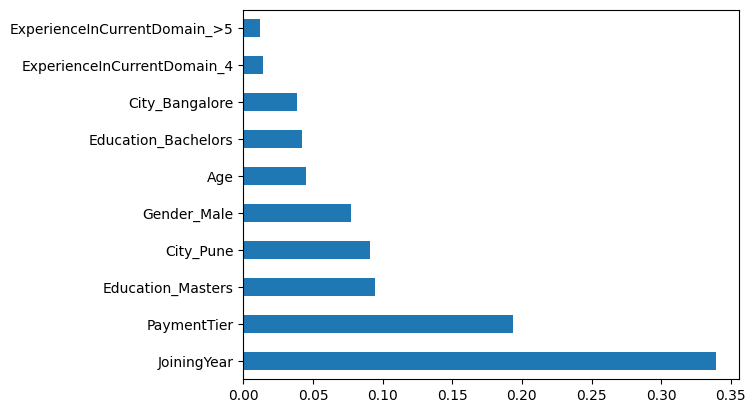

In [17]:
from sklearn import tree
# choose different values for solver 'newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga' 
clf=tree.DecisionTreeClassifier(max_depth=8, criterion='entropy')
DT=clf.fit(X_train, y_train) 
Feature_Importances=pd.Series(DT.feature_importances_,index=predictors)
Feature_Importances.nlargest(10).plot(kind='barh')
prediction=DT.predict(X_test)
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test, prediction, average='weighted')
print('F1_Score:',np.round(F1_Score,2))
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(DT,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
print('Final Accuracy of the Model:',round(np.mean(AccuracyValues),2)*100,'%')

## Selected Logistic Rgression Model for Deployment

## Deploying on Sample Production Data

In [31]:
NewData=pd.DataFrame(data=[
[2017,3,34,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0],
[2013,1,28,1,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0],
[2014,3,38,1,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0],
[2016,3,27,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,1],
[2017,3,24,0,1,0,0,0,1,0,1,0,1,0,0,1,0,0,0],
[2016,3,22,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0],
[2015,3,38,1,0,0,0,1,0,0,1,1,0,1,0,0,0,0,0],
[2016,3,34,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0],
[2016,3,23,1,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0],
[2017,2,37,0,1,0,0,1,0,0,1,1,0,0,0,1,0,0,0],
[2018,2,29,1,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0],
[2015,1,31,0,1,0,0,0,1,0,1,0,1,0,1,0,0,0,0],
[2014,3,41,1,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0],
[2018,3,26,1,0,0,1,0,0,0,1,1,0,0,0,1,0,0,0],
[2019,2,25,0,1,0,0,0,1,1,0,0,1,0,0,0,1,0,0],
[2017,3,35,0,0,1,0,1,0,0,1,1,0,0,0,0,0,0,1],
[2013,1,30,1,0,0,1,0,0,1,0,0,1,1,0,0,0,0,0],
[2015,2,33,1,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0],
[2016,3,28,0,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0],
[2018,3,24,1,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0]
],columns=['JoiningYear', 'PaymentTier', 'Age', 'Education_Bachelors',
       'Education_Masters', 'Education_PHD', 'City_Bangalore',
       'City_New Delhi', 'City_Pune', 'Gender_Female', 'Gender_Male',
       'EverBenched_No', 'EverBenched_Yes', 'ExperienceInCurrentDomain_0',
       'ExperienceInCurrentDomain_1', 'ExperienceInCurrentDomain_2',
       'ExperienceInCurrentDomain_3', 'ExperienceInCurrentDomain_4',
       'ExperienceInCurrentDomain_>5'])

In [25]:
DataForMLEmployeeLeftDataNumeric.columns

Index(['JoiningYear', 'PaymentTier', 'Age', 'Education_Bachelors',
       'Education_Masters', 'Education_PHD', 'City_Bangalore',
       'City_New Delhi', 'City_Pune', 'Gender_Female', 'Gender_Male',
       'EverBenched_No', 'EverBenched_Yes', 'ExperienceInCurrentDomain_0',
       'ExperienceInCurrentDomain_1', 'ExperienceInCurrentDomain_2',
       'ExperienceInCurrentDomain_3', 'ExperienceInCurrentDomain_4',
       'ExperienceInCurrentDomain_>5', 'LeaveOrNot'],
      dtype='str')

In [32]:
newX=NewData.values

In [33]:
DT.predict(newX)

array([0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1])

In [37]:
def GenerateSurvialPred(inpData):
    newX=inpData.values
    # Making sure the new data is also Normalized using the same normalization PredictorScalerFit
    pred=DT.predict(newX)
    inpData['Prediction']=pred
    return(inpData)

In [38]:
GenerateSurvialPred(inpData=NewData)


,JoiningYear,PaymentTier,Age,Education_Bachelors,Education_Masters,Education_PHD,City_Bangalore,City_New Delhi,City_Pune,Gender_Female,Gender_Male,EverBenched_No,EverBenched_Yes,ExperienceInCurrentDomain_0,ExperienceInCurrentDomain_1,ExperienceInCurrentDomain_2,ExperienceInCurrentDomain_3,ExperienceInCurrentDomain_4,ExperienceInCurrentDomain_>5,Prediction
0,2017,3,34,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0,0
1,2013,1,28,1,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,0
2,2014,3,38,1,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0
3,2016,3,27,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,1,1
4,2017,3,24,0,1,0,0,0,1,0,1,0,1,0,0,1,0,0,0,1
5,2016,3,22,1,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0,1
6,2015,3,38,1,0,0,0,1,0,0,1,1,0,1,0,0,0,0,0,0
7,2016,3,34,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0
8,2016,3,23,1,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,1
9,2017,2,37,0,1,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0
